# Notebook 03: Deep Evaluation

This notebook loads the best model saved by `2_Training_Comparison_EuroSAT.ipynb` and performs a thorough evaluation:
- Confusion Matrix (heatmap)
- Per-class Precision, Recall, F1-Score
- Classification Report Heatmap
- Top confused class pairs
- Most & least confident predictions
- Wrong prediction gallery (visual)

**Prerequisite:**
Run `02_Training_Comparison.ipynb` first to generate:
- `./results/best_model_meta.json`
- `./models/<best_model>/best/`

or

Upload `best_model_meta.json` and place it in `/result/best_model_meta.json`
---
📋 **Table of Contents**
1. Install & Imports
2. Load Best Model from Notebook 02
3. Run Predictions on Validation Set
4. Confusion Matrix
5. Per-Class Classification Report
6. Classification Report Heatmap
7. Top Confused Class Pairs
8. Most & Least Confident Predictions
9. Wrong Prediction Gallery
10. Full Summary

# 1. Install & Importing Libraries

In [3]:
!pip -q install transformers datasets evaluate accelerate torchvision scikit-learn matplotlib seaborn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [4]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn.functional as F

from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.metrics import precision_recall_fscore_support
from PIL import Image

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f' Using device: {DEVICE}')

RESULTS_DIR = './results'
os.makedirs(RESULTS_DIR, exist_ok=True)

 Using device: cpu


# 2. Load Best Model Metadata from Notebook 02

In [ ]:
#META_PATH = './results/best_model_meta.json' # USE THIS IF YOU ARE USING COLAB
META_PATH = '/content/drive/MyDrive/mldata/best_model_meta.json' # Change the directory to your desired path

with open(META_PATH, 'r') as f:
    meta = json.load(f)

BEST_MODEL_NAME = meta['best_model_name']
#BEST_MODEL_PATH = meta['best_model_path'] # USE THIS IF YOU ARE USING COLAB
BEST_MODEL_PATH = '/content/drive/MyDrive/mldata' # Change the directory to your desired path
LABELS          = meta['labels']
NUM_CLASSES     = meta['num_classes']

print(f'✅ Loaded metadata from: {META_PATH}')
print(f'   Best model : {BEST_MODEL_NAME}')
print(f'   Model path : {BEST_MODEL_PATH}')
print(f'   Classes    : {LABELS}')

# Load model + processor
image_processor = AutoImageProcessor.from_pretrained(BEST_MODEL_PATH)
model           = AutoModelForImageClassification.from_pretrained(BEST_MODEL_PATH)
model.to(DEVICE)
model.eval()
print(f'\n✅ Model [{BEST_MODEL_NAME}] loaded and ready on {DEVICE}.')

✅ Loaded metadata from: /content/drive/MyDrive/mldata/best_model_meta.json
   Best model : ViT-Base
   Model path : /content/drive/MyDrive/mldata
   Classes    : ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']


The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/200 [00:02<?, ?it/s]


✅ Model [ViT-Base] loaded and ready on cpu.


# 3. Run Predictions on Validation set

In [6]:
SEED      = 42
TEST_SIZE = 0.2

print('Loading dataset...')
dataset  = load_dataset('blanchon/EuroSAT_RGB')
split    = dataset['train'].train_test_split(test_size=TEST_SIZE, seed=SEED)
val_raw  = split['test']

print(f' Validation samples: {len(val_raw):,}')

Loading dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

 Validation samples: 3,240


In [7]:
all_preds   = []
all_labels  = []
all_confs   = []   # confidence = max softmax score
all_images  = []   # keep PIL images for the gallery

BATCH_SIZE = 64
n_batches  = (len(val_raw) + BATCH_SIZE - 1) // BATCH_SIZE

print(f'Running predictions on {len(val_raw):,} samples...')

for i in range(n_batches):
    batch = val_raw.select(range(i * BATCH_SIZE, min((i + 1) * BATCH_SIZE, len(val_raw))))

    images = [img.convert('RGB') for img in batch['image']]
    labels = batch['label']

    inputs = image_processor(images, return_tensors='pt').to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)
        probs   = F.softmax(outputs.logits, dim=-1).cpu().numpy()

    preds = np.argmax(probs, axis=1)
    confs = np.max(probs, axis=1)

    all_preds.extend(preds.tolist())
    all_labels.extend(labels)
    all_confs.extend(confs.tolist())
    all_images.extend(images)

    if (i + 1) % 10 == 0 or (i + 1) == n_batches:
        print(f'  Batch {i+1}/{n_batches} done...')

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_confs  = np.array(all_confs)

overall_acc = (all_preds == all_labels).mean() * 100
print(f'\n✅ Predictions done!')
print(f'   Overall Accuracy: {overall_acc:.2f}%')

Running predictions on 3,240 samples...
  Batch 10/51 done...
  Batch 20/51 done...
  Batch 30/51 done...
  Batch 40/51 done...
  Batch 50/51 done...
  Batch 51/51 done...

✅ Predictions done!
   Overall Accuracy: 98.89%


# 4. Confusion Matrix

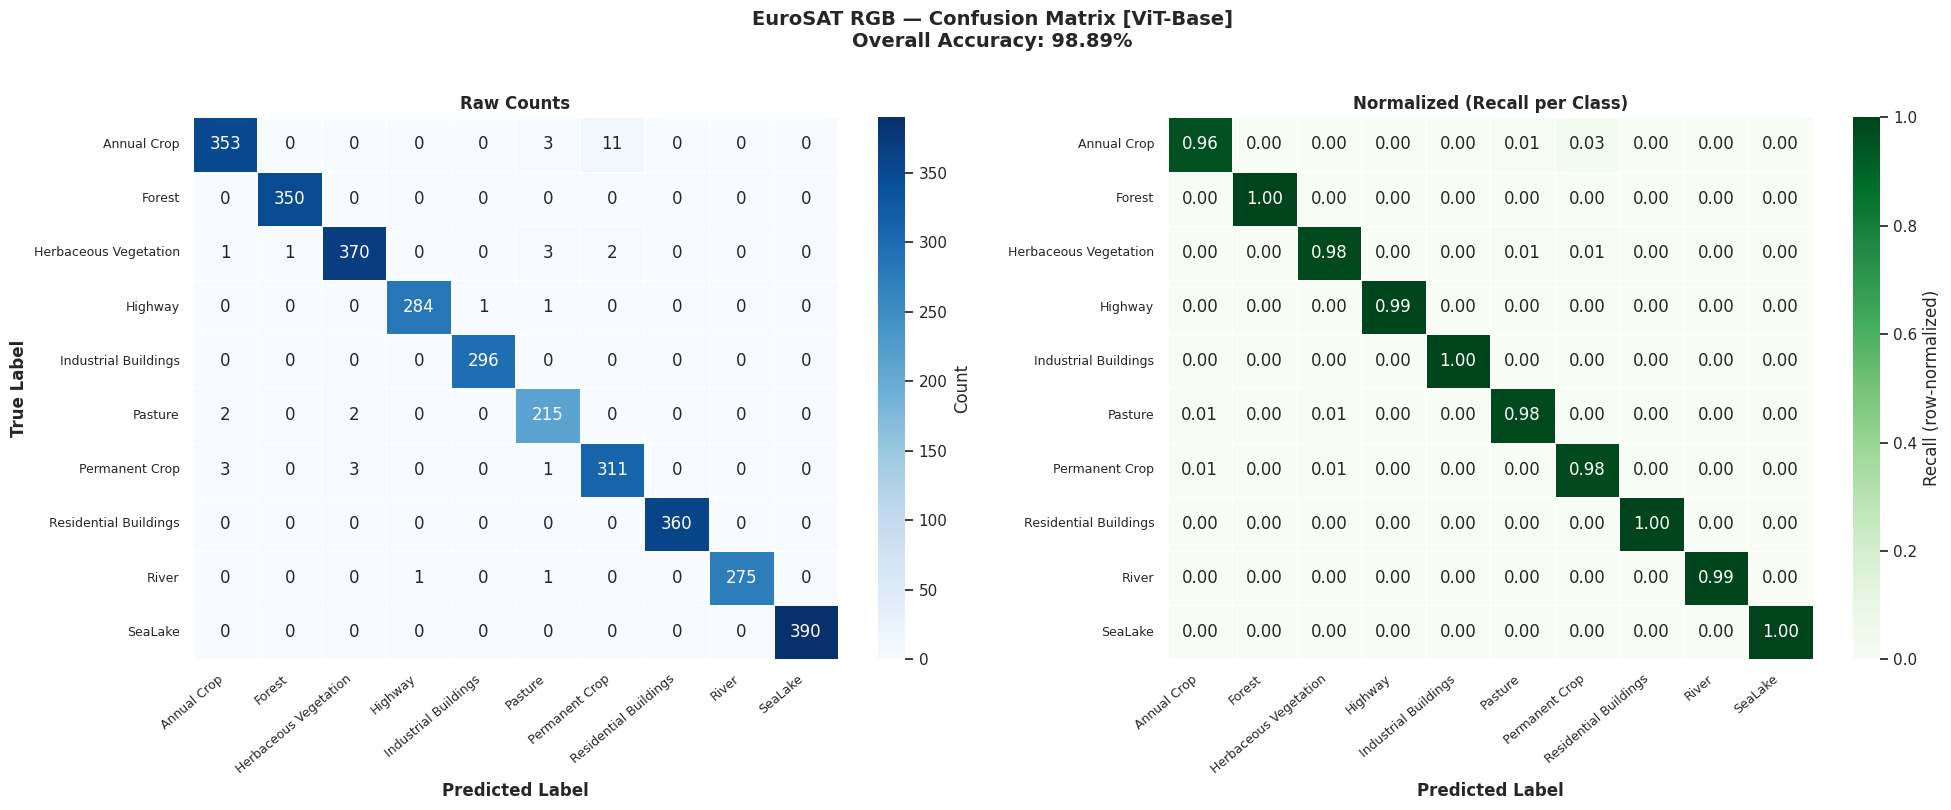

In [8]:
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # normalize by true class

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    f'EuroSAT RGB — Confusion Matrix [{BEST_MODEL_NAME}]\n'
    f'Overall Accuracy: {overall_acc:.2f}%',
    fontsize=14, fontweight='bold', y=1.01
)

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=LABELS, yticklabels=LABELS,
    linewidths=0.4, linecolor='white',
    ax=axes[0], cbar_kws={'label': 'Count'}
)
axes[0].set_title('Raw Counts', fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontweight='bold')
axes[0].set_ylabel('True Label', fontweight='bold')
axes[0].set_xticklabels(LABELS, rotation=40, ha='right', fontsize=9)
axes[0].set_yticklabels(LABELS, rotation=0, fontsize=9)

# Normalized (recall per class)
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Greens',
    xticklabels=LABELS, yticklabels=LABELS,
    linewidths=0.4, linecolor='white',
    ax=axes[1], cbar_kws={'label': 'Recall (row-normalized)'}
)
axes[1].set_title('Normalized (Recall per Class)', fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xticklabels(LABELS, rotation=40, ha='right', fontsize=9)
axes[1].set_yticklabels(LABELS, rotation=0, fontsize=9)

plt.tight_layout()
cm_path = os.path.join(RESULTS_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()

# 5. Per-class Confusion Matrix

In [9]:
report_dict = classification_report(
    all_labels, all_preds,
    target_names=LABELS,
    output_dict=True
)

# Build clean DataFrame (exclude averages rows for the table)
df_report = pd.DataFrame(report_dict).T.drop(
    ['accuracy', 'macro avg', 'weighted avg'], errors='ignore'
)
df_report = df_report[['precision', 'recall', 'f1-score', 'support']].round(4)
df_report.columns = ['Precision', 'Recall', 'F1-Score', 'Support']
df_report['Support'] = df_report['Support'].astype(int)

# Save to CSV
report_csv = os.path.join(RESULTS_DIR, 'classification_report.csv')
df_report.to_csv(report_csv)

print('=' * 60)
print(f'  📊 Per-Class Report — {BEST_MODEL_NAME}')
print('=' * 60)
print(df_report.to_string())
print('-' * 60)
print(f'  Macro Avg  F1 : {report_dict["macro avg"]["f1-score"]:.4f}')
print(f'  Weighted F1   : {report_dict["weighted avg"]["f1-score"]:.4f}')
print(f'  Overall Acc   : {overall_acc:.2f}%')
print('=' * 60)
print(f'\n✅ Report saved to: {report_csv}')

  📊 Per-Class Report — ViT-Base
                       Precision  Recall  F1-Score  Support
Annual Crop               0.9833  0.9619    0.9725      367
Forest                    0.9972  1.0000    0.9986      350
Herbaceous Vegetation     0.9867  0.9814    0.9840      377
Highway                   0.9965  0.9930    0.9947      286
Industrial Buildings      0.9966  1.0000    0.9983      296
Pasture                   0.9598  0.9817    0.9707      219
Permanent Crop            0.9599  0.9780    0.9688      318
Residential Buildings     1.0000  1.0000    1.0000      360
River                     1.0000  0.9928    0.9964      277
SeaLake                   1.0000  1.0000    1.0000      390
------------------------------------------------------------
  Macro Avg  F1 : 0.9884
  Weighted F1   : 0.9889
  Overall Acc   : 98.89%

✅ Report saved to: ./results/classification_report.csv


# 6. Heatmap

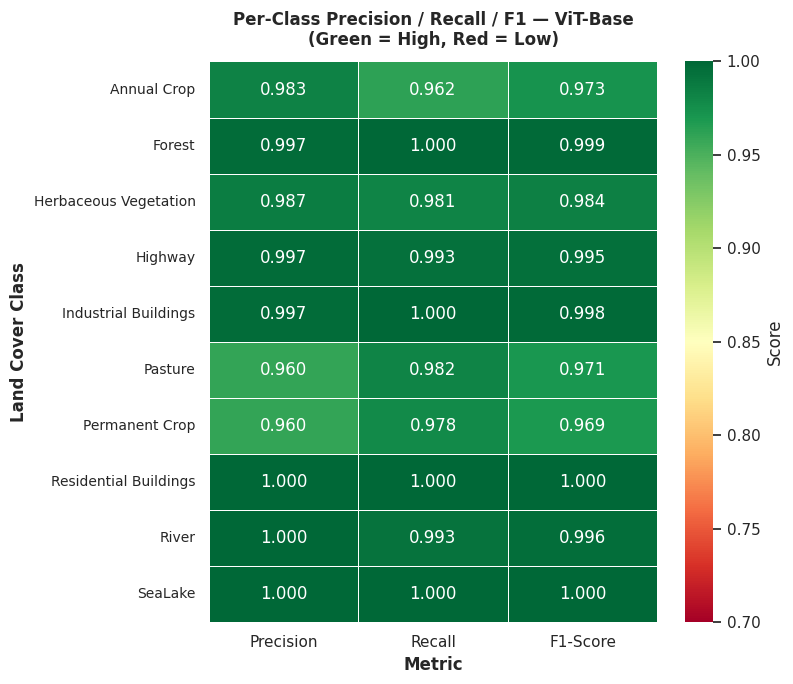

In [10]:
fig, ax = plt.subplots(figsize=(8, 7))

heatmap_data = df_report[['Precision', 'Recall', 'F1-Score']]

sns.heatmap(
    heatmap_data, annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0.7, vmax=1.0,
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Score'}
)

ax.set_title(
    f'Per-Class Precision / Recall / F1 — {BEST_MODEL_NAME}\n'
    f'(Green = High, Red = Low)',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlabel('Metric', fontweight='bold')
ax.set_ylabel('Land Cover Class', fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

# 7 Top Confused Class Pairs

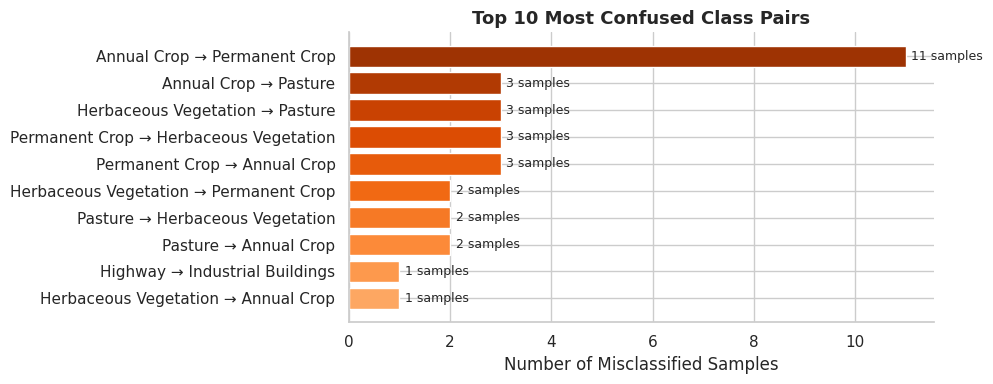

 Top Confused Pairs:
           True Class          Predicted As  Count  Recall Lost (%)
          Annual Crop        Permanent Crop     11              3.0
          Annual Crop               Pasture      3              0.8
Herbaceous Vegetation               Pasture      3              0.8
       Permanent Crop Herbaceous Vegetation      3              0.9
       Permanent Crop           Annual Crop      3              0.9
Herbaceous Vegetation        Permanent Crop      2              0.5
              Pasture Herbaceous Vegetation      2              0.9
              Pasture           Annual Crop      2              0.9
              Highway  Industrial Buildings      1              0.3
Herbaceous Vegetation           Annual Crop      1              0.3


In [11]:
confused_pairs = []

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            confused_pairs.append({
                'True Class'     : LABELS[i],
                'Predicted As'   : LABELS[j],
                'Count'          : cm[i, j],
                'Recall Lost (%)'  : round(cm[i, j] / cm[i].sum() * 100, 1)
            })

df_confused = pd.DataFrame(confused_pairs).sort_values('Count', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 4))
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(df_confused))[::-1])
bars = ax.barh(
    [f"{r['True Class']} → {r['Predicted As']}" for _, r in df_confused.iterrows()],
    df_confused['Count'],
    color=colors, edgecolor='white'
)
ax.bar_label(bars, fmt='%d samples', padding=4, fontsize=9)
ax.set_title('Top 10 Most Confused Class Pairs', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Misclassified Samples')
ax.invert_yaxis()
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print(' Top Confused Pairs:')
print(df_confused.to_string(index=False))

# 8. Most & Least Confident Predictions

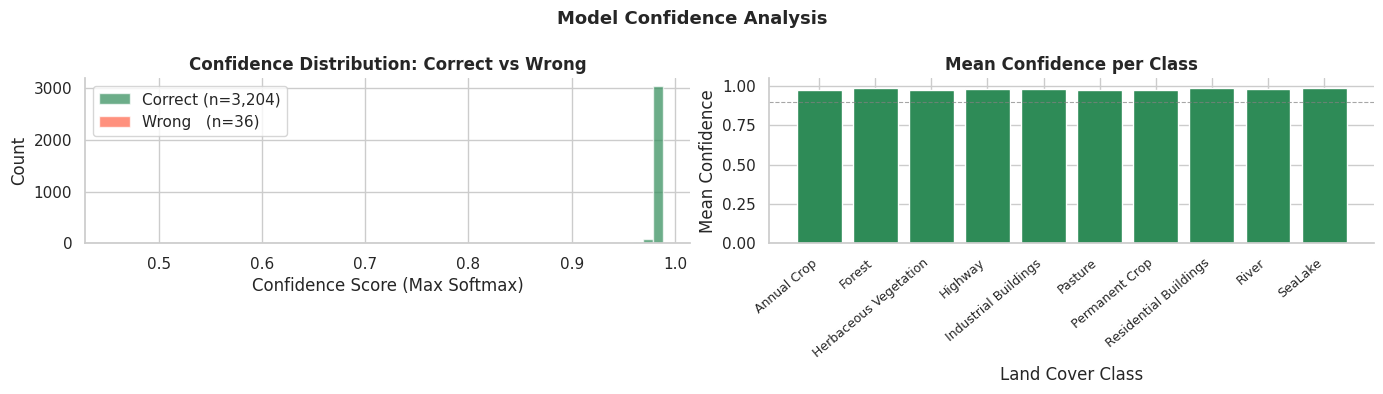

In [12]:
correct_mask   = (all_preds == all_labels)
correct_confs  = all_confs[correct_mask]
wrong_confs    = all_confs[~correct_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(correct_confs, bins=50, alpha=0.7, color='seagreen', label=f'Correct (n={correct_mask.sum():,})')
axes[0].hist(wrong_confs,   bins=50, alpha=0.7, color='tomato',   label=f'Wrong   (n={(~correct_mask).sum():,})')
axes[0].set_title('Confidence Distribution: Correct vs Wrong', fontweight='bold')
axes[0].set_xlabel('Confidence Score (Max Softmax)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Per-class mean confidence
per_class_conf = [all_confs[all_labels == i].mean() for i in range(NUM_CLASSES)]
palette = ['seagreen' if f >= 0.9 else 'goldenrod' if f >= 0.8 else 'tomato'
           for f in per_class_conf]
axes[1].bar(LABELS, per_class_conf, color=palette, edgecolor='white')
axes[1].axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
axes[1].set_title('Mean Confidence per Class', fontweight='bold')
axes[1].set_xlabel('Land Cover Class')
axes[1].set_ylabel('Mean Confidence')
axes[1].set_xticklabels(LABELS, rotation=40, ha='right', fontsize=9)
axes[1].set_ylim(0, 1.05)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Model Confidence Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 9. Wrong Prediction Gallery

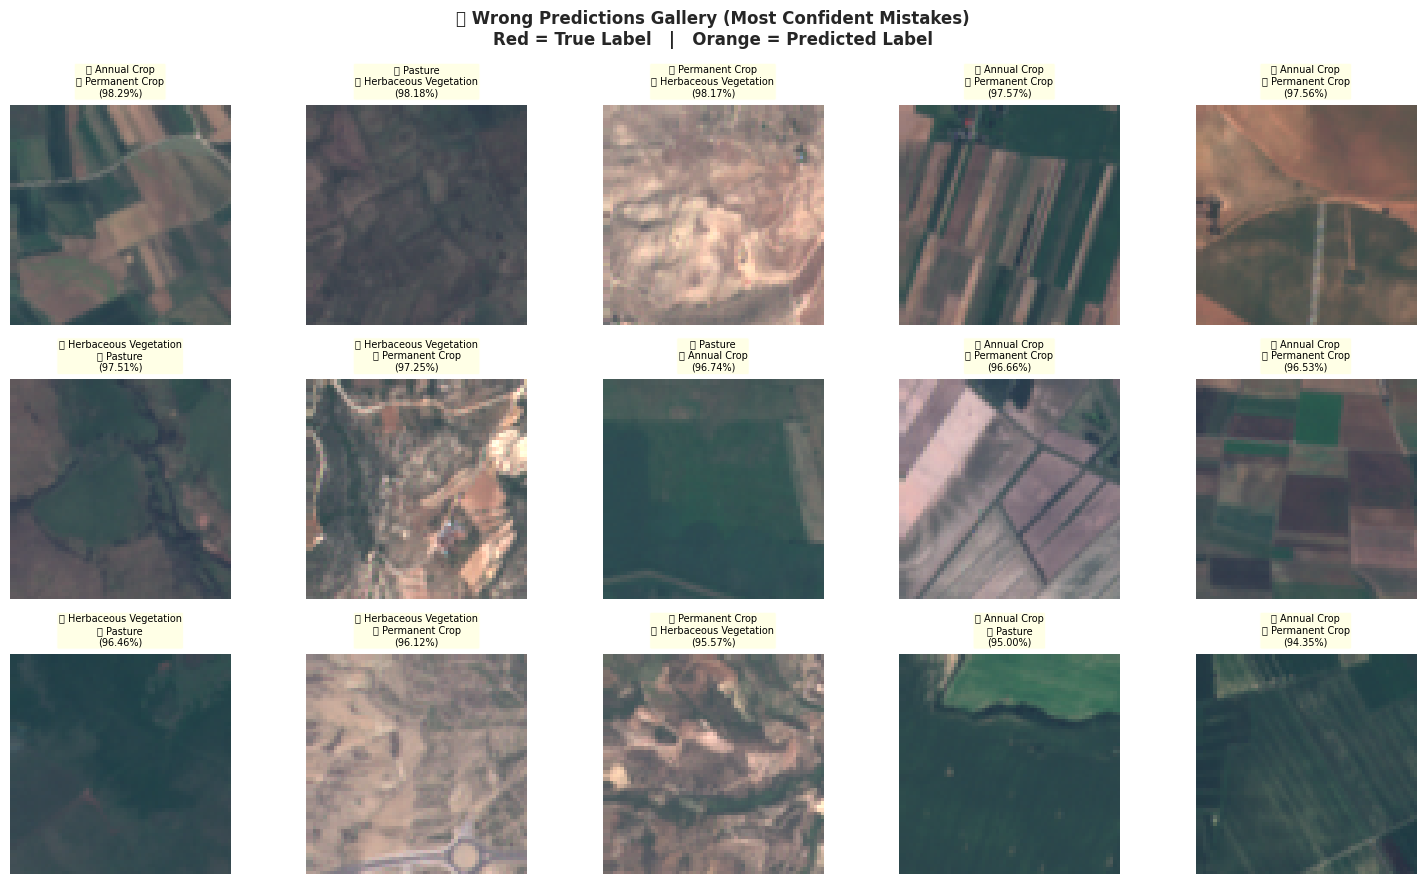

In [13]:
# Shows 15 misclassified images with true vs predicted label
wrong_indices = np.where(all_preds != all_labels)[0]

# Sort by HIGHEST confidence wrong (most "confident mistakes" — most interesting!)
wrong_sorted  = wrong_indices[np.argsort(all_confs[wrong_indices])[::-1]]
gallery_imgs  = wrong_sorted[:15]

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle(
    '❌ Wrong Predictions Gallery (Most Confident Mistakes)\n'
    'Red = True Label   |   Orange = Predicted Label',
    fontsize=12, fontweight='bold'
)

for ax, idx in zip(axes.flat, gallery_imgs):
    ax.imshow(all_images[idx])
    true_lbl = LABELS[all_labels[idx]]
    pred_lbl = LABELS[all_preds[idx]]
    conf_val = all_confs[idx]
    ax.set_title(
        f'✅ {true_lbl}\n❌ {pred_lbl}\n({conf_val:.2%})',
        fontsize=7, color='black',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.8)
    )
    ax.axis('off')

plt.tight_layout()
gallery_path = os.path.join(RESULTS_DIR, 'wrong_prediction_gallery.png')
plt.savefig(gallery_path, dpi=150, bbox_inches='tight')
plt.show()

# 10. Full Summary

Evaluation Summary
- Model            : ViT-Base
- Val Samples      : 3,240
- Overall Accuracy : 98.89%
- Macro Avg F1     : 0.9884
- Weighted F1      : 0.9889
---
- Best Class       : Residential Buildings (F1=1.0000)
- Hardest Class    : Permanent Crop (F1=0.9688)
- Top Confusion    : Annual Crop → Permanent Crop (11 samples)
- Mean Confidence  : 98.13%
- Wrong Predictions: 36 (1.11%)
